# What Is a House Worth, and How Sure Can We Be?

**Question.** The Ames housing dataset records 1,460 home sales with 79 descriptive
features. Thirty-six of those are plain numbers — square footage, room counts, year
built. How much of a sale price can those numbers alone explain, and how confident
should anyone be in that figure?

**The second question is the interesting one.** The original coursework version of this
analysis fit a linear model on one 80/20 split and reported a single R². This notebook
keeps the model and replaces the evaluation, because it turns out that single number was
close to meaningless.

**Headline result.** Five-fold cross-validation puts the model at **R² = 0.83** on
log-price, a typical error of **7.4%** of the sale price. But re-running the original
single-split evaluation under 20 different random seeds produces R² values ranging from
**0.63 to 0.91**. The choice of seed moves the reported score more than most modelling
decisions would.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import KFold, cross_val_predict, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SEED = 42
sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/houses_dataset.csv")
print(f"{len(df)} sales, {df.shape[1]} columns")
df[["OverallQual", "GrLivArea", "GarageArea", "YearBuilt", "SalePrice"]].head()

1460 sales, 81 columns


,OverallQual,GrLivArea,GarageArea,YearBuilt,SalePrice
0,7,1710,548,2003,208500
1,6,1262,460,1976,181500
2,7,1786,608,2001,223500
3,7,1717,642,1915,140000
4,8,2198,836,2000,250000


## 1. The target needs a log

Sale price is right-skewed: a long tail of expensive homes pulls the mean well above the
median. Linear regression assumes errors are symmetric and constant in scale, which a
skewed target violates — the model would spend its capacity chasing mansions.

In [2]:
skew_raw = df.SalePrice.skew()
skew_log = np.log(df.SalePrice).skew()
print(f"skew of SalePrice:      {skew_raw:.3f}")
print(f"skew of log(SalePrice): {skew_log:.3f}")
df.SalePrice.describe().round(0)

skew of SalePrice:      1.883
skew of log(SalePrice): 0.121


count      1460.0
mean     180921.0
std       79443.0
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0
Name: SalePrice, dtype: float64

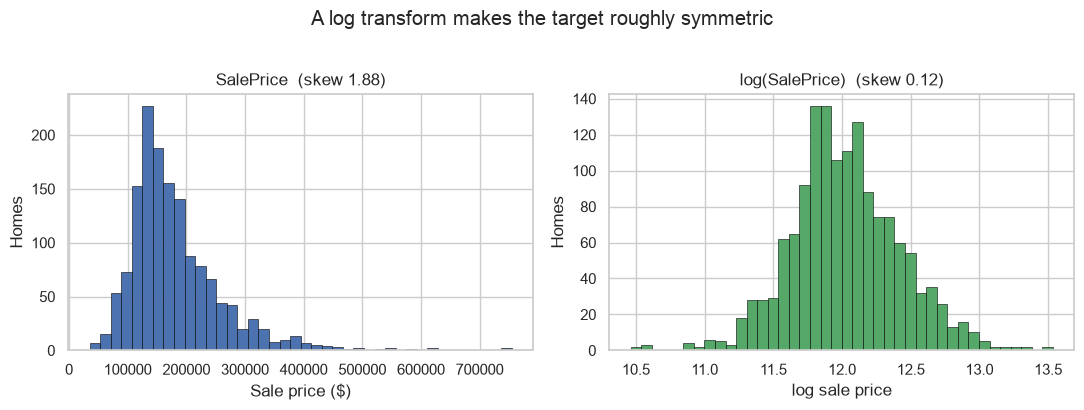

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df.SalePrice, bins=40, color="#4c72b0", edgecolor="black", linewidth=0.4)
axes[0].set_title(f"SalePrice  (skew {skew_raw:.2f})")
axes[0].set_xlabel("Sale price ($)")
axes[1].hist(np.log(df.SalePrice), bins=40, color="#55a868", edgecolor="black", linewidth=0.4)
axes[1].set_title(f"log(SalePrice)  (skew {skew_log:.2f})")
axes[1].set_xlabel("log sale price")
for ax in axes:
    ax.set_ylabel("Homes")
fig.suptitle("A log transform makes the target roughly symmetric", y=1.02)
fig.tight_layout()
fig.savefig("../results/price_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

Everything below models `log(SalePrice)`. That has a consequence worth stating early:
**errors reported in log units are not interpretable.** An RMSE of 0.165 log-dollars
sounds impressive and means nothing to anyone buying a house. Section 4 converts back.

## 2. What actually correlates with price

Before fitting anything, rank the numeric features by their correlation with the target.

In [4]:
numeric = df.select_dtypes(include=[np.number])
corr = numeric.corr()["SalePrice"].sort_values(ascending=False)
corr[1:9].to_frame("correlation with SalePrice").round(3)

,correlation with SalePrice
OverallQual,0.791
GrLivArea,0.709
GarageCars,0.640
GarageArea,0.623
TotalBsmtSF,0.614
1stFlrSF,0.606
FullBath,0.561
TotRmsAbvGrd,0.534


Overall quality leads, then living area, then two garage measures that are largely the
same thing — `GarageCars` and `GarageArea` are near-duplicates. That redundancy matters
for interpreting coefficients later.

## 3. Missing data, and a bug worth naming

Three numeric columns have gaps. The original code handled them with
`train.select_dtypes(include=[np.number]).interpolate().dropna()`, then built the target
separately from the *unfiltered* frame:

```python
data = train.select_dtypes(include=[np.number]).interpolate().dropna()
y = np.log(train.SalePrice)      # 1460 rows
X = data.drop(['SalePrice', 'Id'], axis=1)   # however many survived dropna()
```

If `dropna()` removes any row, `X` and `y` silently describe different sets of houses.

In [5]:
nulls = numeric.isnull().sum()
print(nulls[nulls > 0].to_string())

after = numeric.interpolate().dropna()
print(f"\nrows before: {len(numeric)}   after interpolate().dropna(): {len(after)}")

LotFrontage    259
MasVnrArea       8
GarageYrBlt     81

rows before: 1460   after interpolate().dropna(): 1460


On *this* dataset the bug never fires — interpolation happens to fill every gap, so no
rows are dropped and the two frames stay the same length. It is a latent fault rather
than an active one. Still worth removing: a single leading `NaN` in any column would
have made it real, and the failure would have been silent rather than loud.

Two further problems with `interpolate()` here. It fills by *row order*, which for a
dataset sorted by nothing in particular means borrowing a value from an unrelated house.
And it is applied to the whole dataset before splitting, so information leaks from
validation folds into training.

The replacement is a median imputer inside a pipeline, refit within each fold.

In [6]:
X = numeric.drop(columns=["SalePrice", "Id"])
y = np.log(df.SalePrice)
prices = df.SalePrice.to_numpy()
print(f"X: {X.shape}   y: {y.shape}")

model = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), LinearRegression())
baseline = make_pipeline(SimpleImputer(strategy="median"), DummyRegressor(strategy="mean"))
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

X: (1460, 36)   y: (1460,)


## 4. A baseline, and errors in dollars

An R² with nothing to compare it against is hard to read. The baseline here predicts the
mean log-price for every house — the score any model must beat to be worth its
complexity.

Predictions come from `cross_val_predict`, so every house is predicted by a model that
never saw it.

In [7]:
def evaluate(name, estimator, features=X, target=y, actual=prices):
    pred_log = cross_val_predict(estimator, features, target, cv=cv)
    pred_dollars = np.exp(pred_log)
    return {
        "model": name,
        "R² (log)": r2_score(target, pred_log),
        "RMSE (log)": root_mean_squared_error(target, pred_log),
        "MAE ($)": mean_absolute_error(actual, pred_dollars),
        "RMSE ($)": root_mean_squared_error(actual, pred_dollars),
        "median abs % error": 100 * np.median(np.abs(pred_dollars - actual) / actual),
    }


results = pd.DataFrame([
    evaluate("baseline — predict the mean", baseline),
    evaluate("linear regression, 36 features", model),
])
results.set_index("model").round(3)

,R² (log),RMSE (log),MAE ($),RMSE ($),median abs % error
model,,,,,
baseline — predict the mean,-0.001,0.400,55655.366,80701.623,25.356
"linear regression, 36 features",0.829,0.165,20136.548,88820.857,7.428


The model is a large improvement on the baseline by every measure but one. Median
absolute error drops from **25.4%** to **7.4%** of sale price; mean absolute error falls
from about \$56k to \$20k.

**RMSE in dollars gets *worse* than the baseline.** That is not a typo, and it is the
most informative number in the table. Squared error is dominated by the largest misses,
and back-transforming from log space turns a modest log-scale error on an expensive home
into an enormous dollar error. The model is much better on a typical house and much
worse on a handful of atypical ones.

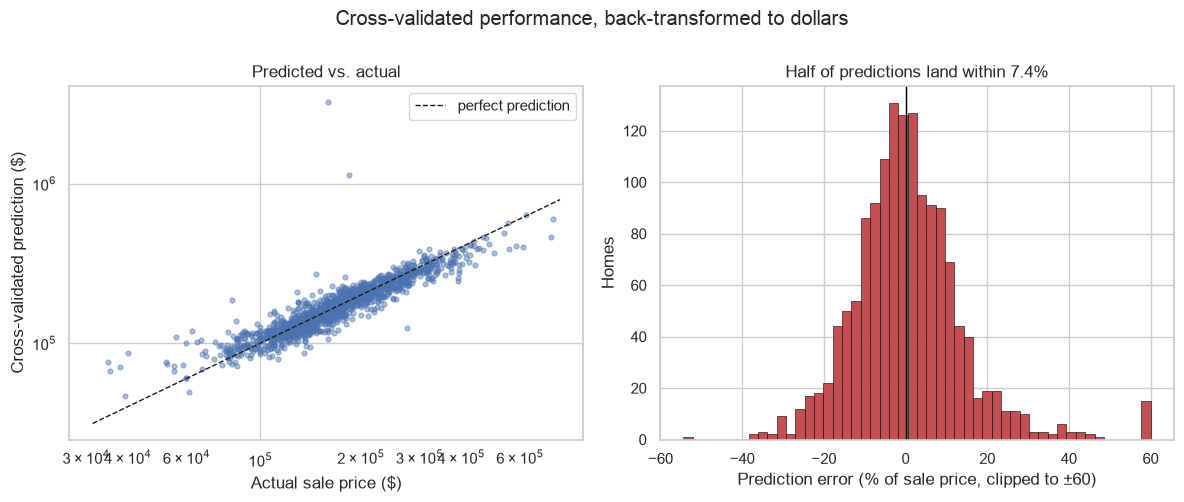

In [8]:
pred_log = cross_val_predict(model, X, y, cv=cv)
pred_dollars = np.exp(pred_log)
err = pred_dollars - prices

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(prices, pred_dollars, s=12, alpha=0.45, color="#4c72b0")
lims = [prices.min() * 0.9, prices.max() * 1.05]
axes[0].plot(lims, lims, "k--", linewidth=1, label="perfect prediction")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Actual sale price ($)")
axes[0].set_ylabel("Cross-validated prediction ($)")
axes[0].set_title("Predicted vs. actual")
axes[0].legend()

pct = 100 * err / prices
axes[1].hist(np.clip(pct, -60, 60), bins=50, color="#c44e52", edgecolor="black", linewidth=0.4)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_xlabel("Prediction error (% of sale price, clipped to ±60)")
axes[1].set_ylabel("Homes")
axes[1].set_title(f"Half of predictions land within {np.median(np.abs(pct)):.1f}%")

fig.suptitle("Cross-validated performance, back-transformed to dollars", y=1.00)
fig.tight_layout()
fig.savefig("../results/predicted_vs_actual.png", dpi=120, bbox_inches="tight")
plt.show()

In [9]:
worst = pd.DataFrame({
    "actual": prices,
    "predicted": pred_dollars.round(0),
    "error": err.round(0),
    "GrLivArea": df.GrLivArea,
    "OverallQual": df.OverallQual,
}).reindex(np.argsort(-np.abs(err))[:5])
worst

,actual,predicted,error,GrLivArea,OverallQual
1298,160000,3253542.0,3093542.0,5642,10
523,184750,1127409.0,942659.0,4676,10
1182,745000,459582.0,-285418.0,4476,10
898,611657,402800.0,-208857.0,2364,9
803,582933,405815.0,-177118.0,2822,9


The worst misses are the extremes — very large or very unusual homes, where a
36-feature linear model has little to work with.

## 5. The headline: one split is not an evaluation

The original analysis fit on one `train_test_split(..., random_state=0)` and reported
`model.score(X_test, y_test)`. Nothing about that is unusual; it is what most tutorials
show. The question is how much the answer depends on the seed.

Here is the same procedure, 20 times, changing only `random_state`.

In [10]:
split_scores = []
for rs in range(20):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=rs)
    split_scores.append(make_pipeline(
        SimpleImputer(strategy="median"), StandardScaler(), LinearRegression()
    ).fit(X_tr, y_tr).score(X_te, y_te))

split_scores = np.array(split_scores)
cv_score = r2_score(y, pred_log)

print(f"single-split R², 20 seeds: min {split_scores.min():.3f}  "
      f"max {split_scores.max():.3f}  spread {np.ptp(split_scores):.3f}")
print(f"5-fold cross-validated R²: {cv_score:.3f}")
print(f"\nseed 0 (the original's choice) gave {split_scores[0]:.3f}")

single-split R², 20 seeds: min 0.626  max 0.907  spread 0.282
5-fold cross-validated R²: 0.829

seed 0 (the original's choice) gave 0.708


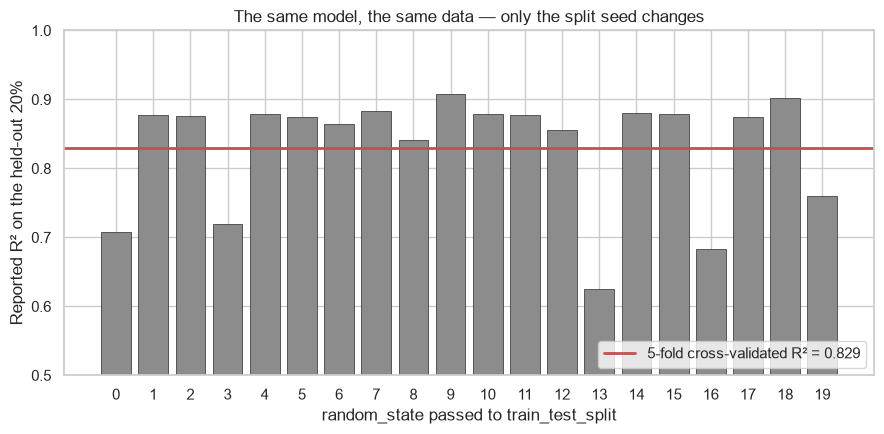

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(range(20), split_scores, color="#8c8c8c", edgecolor="black", linewidth=0.4)
ax.axhline(cv_score, color="#c44e52", linewidth=2,
           label=f"5-fold cross-validated R² = {cv_score:.3f}")
ax.set_xlabel("random_state passed to train_test_split")
ax.set_ylabel("Reported R² on the held-out 20%")
ax.set_xticks(range(20))
ax.set_ylim(0.5, 1.0)
ax.set_title("The same model, the same data — only the split seed changes")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig("../results/split_variance.png", dpi=120, bbox_inches="tight")
plt.show()

A spread of **0.28 in R²** from nothing but the seed. A practitioner who tried three
seeds and reported the best would look like they had improved the model by more than any
feature-engineering step in this notebook achieved. The cross-validated figure sits
inside the range and does not move when the seed changes, because every house is in the
test fold exactly once.

This is why the rest of this notebook reports cross-validated numbers only.

## 6. How far does one feature get you?

The original also fit single-feature models against `GarageArea` and `OverallQual`.
Scored the same way as the full model, they set a useful middle ground between the
baseline and 36 features.

In [12]:
single = pd.DataFrame([
    evaluate(f"{f} only", model, features=X[[f]])
    for f in ["GarageArea", "GrLivArea", "OverallQual"]
] + [evaluate("all 36 numeric features", model)])
single.set_index("model")[["R² (log)", "median abs % error"]].round(3)

,R² (log),median abs % error
model,,
GarageArea only,0.423,16.729
GrLivArea only,0.484,15.056
OverallQual only,0.666,13.065
all 36 numeric features,0.829,7.428


`OverallQual` alone — a single 1–10 subjective rating from the assessor — reaches R² =
0.67, four-fifths of what all 36 features manage. Most of what the model knows, it knows
from one human judgement about the house.

## 7. A trap: removing outliers to improve the score

The original filtered rows where any feature had |z| > 3, then fit on what remained. The
score goes up. It is worth being precise about why that is not an improvement.

In [13]:
X_filled = X.fillna(X.median())
keep = (np.abs(stats.zscore(X_filled)) < 3).all(axis=1)
print(f"|z| < 3 on all {X.shape[1]} features keeps {keep.sum()} of {len(X)} rows "
      f"({100 * keep.mean():.1f}%)")

filtered = evaluate("after |z| < 3 filtering", model,
                    features=X[keep], target=y[keep], actual=prices[keep])
comparison = pd.DataFrame([evaluate("all rows", model), filtered])
comparison.set_index("model")[["R² (log)", "median abs % error"]].round(3)

|z| < 3 on all 36 features keeps 1021 of 1460 rows (69.9%)


,R² (log),median abs % error
model,,
all rows,0.829,7.428
after |z| < 3 filtering,0.896,5.961


R² rises from 0.83 to 0.90 — while discarding **30% of the data**. Requiring 36
simultaneous z-scores below 3 is a demanding filter; it removes not just data-entry
errors but every genuinely large, old, or unusual house in Ames.

The higher number describes a different and easier problem: predicting prices for
ordinary houses only. If the eventual use is valuing arbitrary homes, the honest score
is 0.83. Reporting 0.90 without saying what was dropped would overstate the model by
more than the model is worth.

## 8. What the model learned

In [14]:
fitted = model.fit(X, y)
coefs = pd.Series(fitted[-1].coef_, index=X.columns).sort_values(key=abs, ascending=False)
coefs.head(10).to_frame("coefficient (standardised features, log target)").round(4)

,"coefficient (standardised features, log target)"
OverallQual,0.1168
YearBuilt,0.0905
OverallCond,0.0540
GrLivArea,0.0527
GarageCars,0.0495
1stFlrSF,0.0368
BsmtFullBath,0.0329
2ndFlrSF,0.0305
Fireplaces,0.0291
MSSubClass,-0.0273


Coefficients are on standardised features, so they compare directly: a one-standard-
deviation increase in `OverallQual` is worth roughly 0.12 in log-price, about 12%.

These should be read as associations, not levers. `GarageCars` and `GarageArea` measure
nearly the same thing, and correlated predictors split a shared effect between them in
arbitrary proportions. The ranking is suggestive; the individual magnitudes are not
stable.

## Findings

1. Thirty-six numeric features explain **R² = 0.83** of log sale price under five-fold
   cross-validation, with a **median error of 7.4%** — roughly ±\$12k on a median
   \$163k home. A predict-the-mean baseline errs by 25.4%.
2. **A single train/test split cannot support a reported score here.** Twenty seeds
   produce R² from 0.63 to 0.91. This is the finding that changed the analysis.
3. Dollar RMSE is *worse* than baseline while every other metric is far better. The
   model is reliable on typical homes and unreliable on expensive ones; a single summary
   statistic hides that.
4. `OverallQual` alone reaches R² = 0.67. One assessor's judgement carries most of the
   signal.
5. Outlier filtering lifts R² to 0.90 by discarding 30% of the data. That is a different
   question, not a better answer.

## Limitations

- **Only numeric columns are used.** Neighborhood, which realtors would call the
  dominant factor, is categorical and excluded here. Encoding it would likely help.
- **Linear model, no interactions.** Quality and size almost certainly interact; an
  additive model cannot represent that.
- **Ames, Iowa, 2006–2010.** The period spans the housing crash. Nothing here transfers
  to another market or another decade.
- **Correlated predictors** make individual coefficients unstable, as noted above.
- Errors on homes above roughly \$400k are large enough that the model should not be
  used there.

## Outputs

- `results/price_distribution.png`
- `results/predicted_vs_actual.png`
- `results/split_variance.png`